In [54]:
%load_ext autoreload
%autoreload 2
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools
from scipy.constants import year

from src import file_io as fio

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
# chandra low high table
raw_chandra = [
    ["pha_a", 3.00, 30.00],
    ["pha_b", 3.00, 45.00],
    ["pha_c", 16.07, 166.70],
    ["pha_d", 20.00, 225.00],
    ["pha_e", 20.00, 225.00]
]
factor_chandra = pd.DataFrame(data=raw_chandra, columns=["detector", 0, 1])
factor_chandra.set_index("detector", inplace=True)

# magic number in chandra paper pha = tlm/1023 * factor
magic_chandra = 1023

In [56]:
#quick test
factor_chandra.loc["pha_c", 0]

np.float64(16.07)

In [57]:
def calc_de_dx(row):
    return row["pha_a"] / magic_chandra * factor_chandra.loc["pha_a", row["a_lh_flag"]]

def calc_total_energy(row):
    apply_factors =  row["pha_a"] * factor_chandra.loc["pha_a", row["a_lh_flag"]] + \
                     row["pha_b"] * factor_chandra.loc["pha_b", row["b_lh_flag"]] + \
                     row["pha_c"] * factor_chandra.loc["pha_c", row["c_lh_flag"]] + \
                     row["pha_d"] * factor_chandra.loc["pha_d", row["d_lh_flag"]] + \
                     row["pha_e"] * factor_chandra.loc["pha_e", row["e_lh_flag"]]
    return apply_factors / magic_chandra

In [58]:
path = fio.get_data_files("phx", "1996", "67")[0]
df = fio.read_pha(path)

df = df[(df["a_seg"] == 0) & (df["a_seg"] == df["b_seg"])]
df["de/dx"] = df.apply(calc_de_dx, axis=1)
df["total_energy"] = df.apply(calc_total_energy, axis=1)

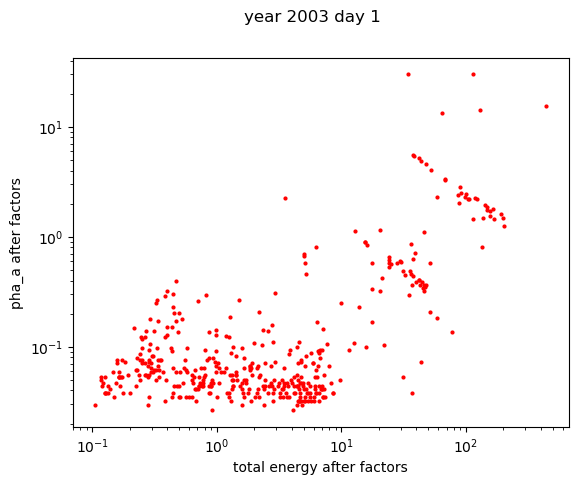

<Figure size 640x480 with 0 Axes>

In [60]:
fig, ax = plt.subplots()
ax.set_xlabel("total energy after factors")
ax.set_xscale('log')
ax.set_ylabel("pha_a after factors")
ax.set_yscale('log')
ax.scatter(df["total_energy"], df["de/dx"], s=4, c='r')
fig.suptitle("year 2003 day 1")
plt.show()
plt.clf()

In [61]:
# now do it again for a week in 1996

files_1996 = fio.get_data_files("phx", "1996")
accum = pd.concat([fio.read_pha(f) for f in files_1996])

In [74]:
filtered = accum[(accum["a_seg"] == 0) & (accum["a_seg"] == accum["b_seg"])]
filtered["de/dx"] = filtered.apply(calc_de_dx, axis=1)
filtered["total_energy"] = filtered.apply(calc_total_energy, axis=1)

In [ ]:
# filtered = filtered[(filtered["total_energy"] != 0) & (filtered["de/dx" != 0])]
filtered["log_energy"] = np.log10(filtered["total_energy"])
filtered["log_de_dx"] = np.log10(filtered["de/dx"])
filtered["log_sum"] = filtered["log_energy"] + filtered["log_de_dx"]

In [85]:
maybe_protons = filtered.loc[filtered["log_sum"].between(0.8, 1.4)]
maybe_he = filtered.loc[filtered["log_sum"].between(2.1, 2.6)]

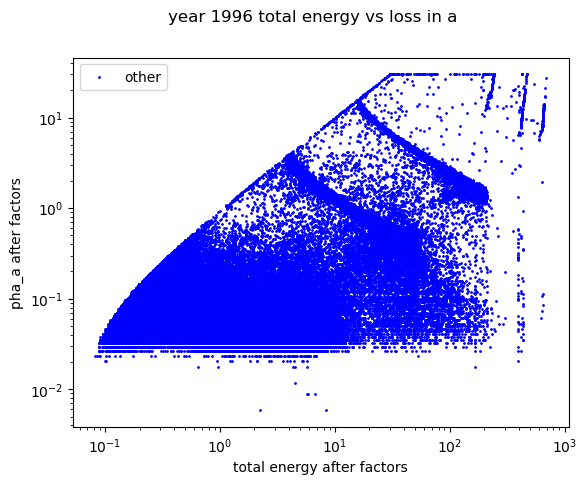

<function matplotlib.pyplot.clf() -> 'None'>

In [87]:
fig, ax = plt.subplots()
ax.set_xlabel("total energy after factors")
ax.set_xscale("log")
ax.set_ylabel("pha_a after factors")
ax.set_yscale("log")


ax.scatter(filtered["total_energy"], filtered["de/dx"], s=1, c='blue', label="other")
# ax.scatter(maybe_protons["total_energy"], maybe_protons["de/dx"], s=1, c='green', label="maybe protons")
# ax.scatter(maybe_he["total_energy"], maybe_he["de/dx"], s=1, c='red', label="maybe helion")

ax.legend()

fig.suptitle("year 1996 total energy vs loss in a")
plt.show()
plt.clf